
# Time Series Analysis: GTI Tourism & Tourist Arrivals


## 1. Setup and Configuration

In [1]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

# USER CONFIGURATION - Modify these variables as needed
FILE_PATH = "tourism_data_final_clean.csv"  # or "your_data.xlsx"
DATE_COLUMN = "date"
INDICATOR_1 = "Tourism_Index"      # First indicator (e.g., Google Trends Index)
INDICATOR_2 = "Tourist_Arrivals"  # Second indicator (e.g., actual arrivals)

## 2. Load Data

In [2]:
# Load tourism data
DATA_DIR = '../data/'
df = pd.read_csv(DATA_DIR + 'tourism_data_final_clean.csv', index_col=0, parse_dates=True)
df = df.sort_values(df.index.name).reset_index()

print("✓ Tourism data loaded")
print(df.shape)
display(df.head())



✓ Tourism data loaded
(197, 7)


,date,travel to Maldives,trip to Maldives,visit Maldives,Tourism_Index,Smoothed_Tourism,Tourist_Arrivals
0,2010-01-01,-0.825008,-1.706328,-1.059997,-1.096982,NaN,67478.0
1,2010-02-01,-1.045956,-1.727994,-1.691463,-1.384784,NaN,77063.0
2,2010-03-01,-1.270348,-1.700412,-1.116677,-1.451536,NaN,74975.0
3,2010-04-01,-1.012232,-1.577281,-1.166211,-1.386326,-1.409334,60742.0
4,2010-05-01,-0.765338,-1.703290,-0.922250,-1.188168,-1.367642,58324.0


## 3. Create Analysis DataFrame with Calculations

In [3]:
# Introduce lags, YOY changes, etc. 
def create_analysis_df(df, date_col, ind1, ind2):
    """
    Create analysis dataframe with:
    - Lag columns (1, 2, 3 months) for indicator 1
    - YoY (Year-over-Year) changes for both indicators
    """
    
    # Start with date and two main indicators
    result = df[[date_col, ind1, ind2]].copy()
    
    # === LAG COLUMNS (D, E, F equivalent) ===
    result[f'{ind1}_lag1'] = result[ind1].shift(1)
    result[f'{ind1}_lag2'] = result[ind1].shift(2)
    result[f'{ind1}_lag3'] = result[ind1].shift(3)
    
    # # === YEAR-OVER-YEAR CALCULATIONS (K, L equivalent) ===
    # result[f'{ind1}_yoy'] = result[ind1].pct_change(periods=12)
    # result[f'{ind2}_yoy'] = result[ind2].pct_change(periods=12)
    
    return result

## 4. Correlation Calculations

In [4]:
# %%
def calculate_correlations(df, ind1, ind2):
    """Calculate correlations between indicators and their transformations."""
    
    correlations = {}
    
    # Correlation between raw values
    mask = df[ind1].notna() & df[ind2].notna()
    if mask.sum() > 2:
        correlations['raw_correlation'] = df.loc[mask, ind1].corr(df.loc[mask, ind2])
    
    # Correlation with lags
    for lag in [1, 2, 3]:
        lag_col = f'{ind1}_lag{lag}'
        if lag_col in df.columns:
            mask = df[lag_col].notna() & df[ind2].notna()
            if mask.sum() > 2:
                correlations[f'lag{lag}_correlation'] = df.loc[mask, lag_col].corr(df.loc[mask, ind2])
    
    return correlations

## 5. Visualization Functions

In [5]:
def plot_comparison(df, date_col, col1, col2, title=None):
    """
    Create a line graph comparing two columns with date on x-axis.
    Displays correlation at the top of the chart.
    """
    
    # Calculate correlation
    mask = df[col1].notna() & df[col2].notna()
    if mask.sum() > 2:
        correlation = df.loc[mask, col1].corr(df.loc[mask, col2])
    else:
        correlation = np.nan
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot both series
    ax.plot(df[date_col], df[col1], label=col1, linewidth=1.5, alpha=0.8)
    ax.plot(df[date_col], df[col2], label=col2, linewidth=1.5, alpha=0.8)
    
    # Title with correlation
    if title:
        chart_title = f"{title}\nCorrelation: {correlation:.4f}"
    else:
        chart_title = f"{col1} vs {col2}\nCorrelation: {correlation:.4f}"
    
    ax.set_title(chart_title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    return fig, correlation


def plot_multiple_comparisons(df, date_col, base_col, comparison_cols, titles=None):
    """
    Create multiple comparison charts in a grid layout.
    """
    n_charts = len(comparison_cols)
    n_cols = min(2, n_charts)
    n_rows = (n_charts + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
    if n_charts == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    correlations = {}
    
    for i, comp_col in enumerate(comparison_cols):
        ax = axes[i]
        
        # Calculate correlation
        mask = df[base_col].notna() & df[comp_col].notna()
        if mask.sum() > 2:
            corr = df.loc[mask, base_col].corr(df.loc[mask, comp_col])
        else:
            corr = np.nan
        
        correlations[comp_col] = corr
        
        # Plot
        ax.plot(df[date_col], df[base_col], label=base_col, linewidth=1.5, alpha=0.8)
        ax.plot(df[date_col], df[comp_col], label=comp_col, linewidth=1.5, alpha=0.8)
        
        title = titles[i] if titles else f"{base_col} vs {comp_col}"
        ax.set_title(f"{title}\nCorrelation: {corr:.4f}", fontsize=12, fontweight='bold')
        ax.set_xlabel('Date')
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    # Hide empty subplots
    for i in range(n_charts, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    return fig, correlations

## 6. Main Execution

In [10]:
# === MAIN EXECUTION ===
# Uncomment and run after configuring your data

# Load data

# Create analysis dataframe
df_analysis = create_analysis_df(df, DATE_COLUMN, INDICATOR_1, INDICATOR_2)

# Display first few rows
print("Analysis DataFrame:")
display(df_analysis.head(20))

# Calculate correlations
correlations = calculate_correlations(df_analysis, INDICATOR_1, INDICATOR_2)
print("\nCorrelations:")
for key, value in correlations.items():
    print(f"  {key}: {value:.4f}")

# # Save to CSV
# df_analysis.to_csv("analysis_output.csv", index=False)
# print("\nSaved to analysis_output.csv")


Analysis DataFrame:


,date,Tourism_Index,Tourist_Arrivals,Tourism_Index_lag1,Tourism_Index_lag2,Tourism_Index_lag3
0,2010-01-01,-1.096982,67478.0,NaN,NaN,NaN
1,2010-02-01,-1.384784,77063.0,-1.096982,NaN,NaN
2,2010-03-01,-1.451536,74975.0,-1.384784,-1.096982,NaN
3,2010-04-01,-1.386326,60742.0,-1.451536,-1.384784,-1.096982
4,2010-05-01,-1.188168,58324.0,-1.386326,-1.451536,-1.384784
5,2010-06-01,-1.256262,44050.0,-1.188168,-1.386326,-1.451536
6,2010-07-01,-1.255068,57232.0,-1.256262,-1.188168,-1.386326
7,2010-08-01,-0.844554,66315.0,-1.255068,-1.256262,-1.188168
8,2010-09-01,-1.175662,62524.0,-0.844554,-1.255068,-1.256262
9,2010-10-01,-1.154501,74707.0,-1.175662,-0.844554,-1.255068



Correlations:
  raw_correlation: 0.6040
  lag1_correlation: 0.6014
  lag2_correlation: 0.5478
  lag3_correlation: 0.5279


## 7. Create Visualizations

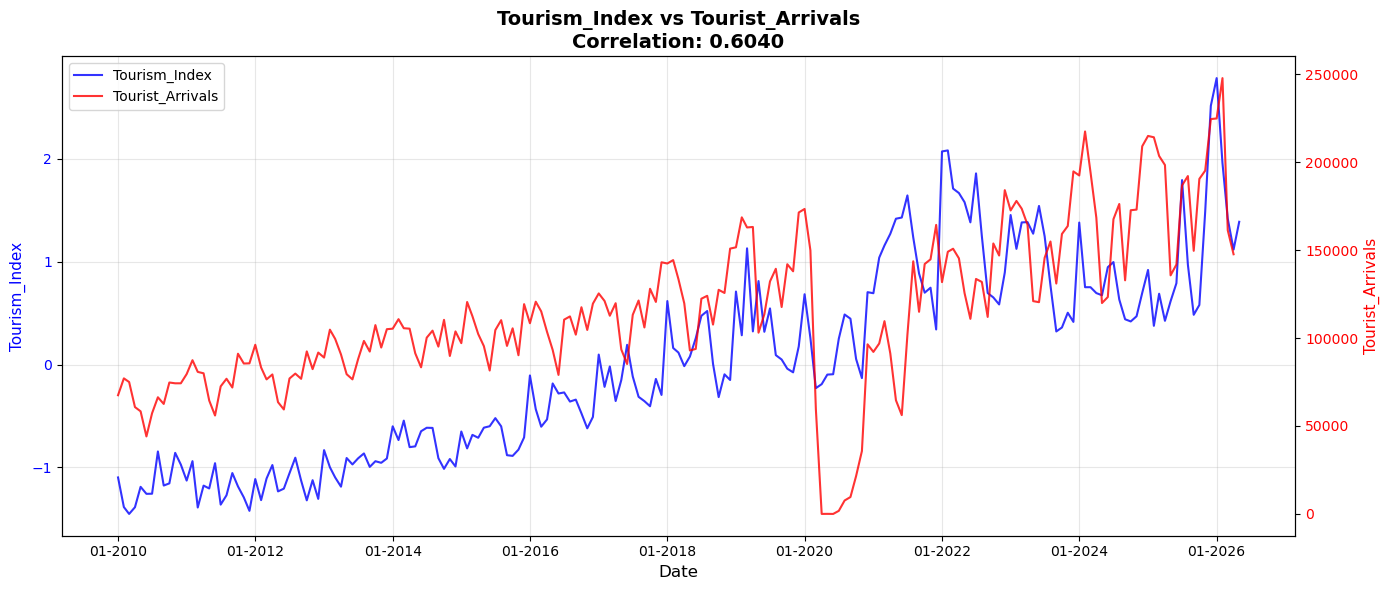

In [11]:
def plot_dual_axis(df, date_col, col1, col2, title=None, date_format="%m-%Y"):
    """
    Create a line graph with two y-axes (secondary axis for col2).
    Displays correlation at the top of the chart.
    
    Parameters:
        df: DataFrame
        date_col: Name of date column
        col1: Column for primary y-axis (left)
        col2: Column for secondary y-axis (right)
        title: Chart title (optional)
        date_format: Format for x-axis date labels (default: MM-YYYY)
    """
    
    # Calculate correlation
    mask = df[col1].notna() & df[col2].notna()
    if mask.sum() > 2:
        correlation = df.loc[mask, col1].corr(df.loc[mask, col2])
    else:
        correlation = np.nan
    
    # Create figure with dual axes
    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax2 = ax1.twinx()  # Create secondary y-axis
    
    # Plot col1 on primary axis (left)
    line1 = ax1.plot(df[date_col], df[col1], color='blue', linewidth=1.5, alpha=0.8, label=col1)
    ax1.set_ylabel(col1, color='blue', fontsize=11)
    ax1.tick_params(axis='y', labelcolor='blue')
    
    # Plot col2 on secondary axis (right)
    line2 = ax2.plot(df[date_col], df[col2], color='red', linewidth=1.5, alpha=0.8, label=col2)
    ax2.set_ylabel(col2, color='red', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='red')
    
    # Title with correlation
    if title:
        chart_title = f"{title}\nCorrelation: {correlation:.4f}"
    else:
        chart_title = f"{col1} vs {col2}\nCorrelation: {correlation:.4f}"
    
    ax1.set_title(chart_title, fontsize=14, fontweight='bold')
    ax1.set_xlabel('Date', fontsize=12)
    
    # Format x-axis dates
    ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter(date_format))
    plt.xticks(rotation=45)
    
    # Combined legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left')
    
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    
    return fig, correlation

# Single dual-axis chart
fig1, corr1 = plot_dual_axis(
    df_analysis, 
    DATE_COLUMN, 
    f'{INDICATOR_1}',           # Primary axis (left)
    f'{INDICATOR_2}', # Secondary axis (right)
    title=f"{INDICATOR_1} vs {INDICATOR_2}"
)
plt.show()


## 8. Test for stationarity

**The Dickey-Fuller test**

The Dickey-Fuller test is a statistical test used to determine if a time series is stationary. A stationary time series is one whose statistical properties, such as mean and variance, do not change over time. The test assumes a null hypothesis that the time series has a unit root, which means it is non-stationary. If the p-value obtained from the test is less than a chosen significance level (commonly 0.05), you reject the null hypothesis and conclude that the time series is stationary.
https://www.statsmodels.org/stable/examples/notebooks/generated/stationarity_detrending_adf_kpss.html#ADF-test

In [12]:
ADF_df = df.copy()
ADF_df.dropna(inplace=True)

# Assuming df is your DataFrame with the columns you want to test
columns_to_test = ['Tourism_Index', 'Tourist_Arrivals']
# Iterate through the selected columns and perform ADF test
for col in columns_to_test:
    result = adfuller(ADF_df[col])
    print(f'Augmented Dickey-Fuller Test for "{col}"')
    print('-' * 47)
    print(f'Null Hypothesis: Data has a unit root. Non-Stationary.')
    print(f'Significance Level = 0.05')
    print(f'Test Statistic = {result[0]}')
    print(f'P-value = {result[1]}')
    print('Critical Values:')
    for key, val in result[4].items():
        print(f'   {key}: {val}')
    print('Is the series stationary? Yes' if result[1] <= 0.05 else 'Is the series stationary? No')
    print('-' * 47)



Augmented Dickey-Fuller Test for "Tourism_Index"
-----------------------------------------------
Null Hypothesis: Data has a unit root. Non-Stationary.
Significance Level = 0.05
Test Statistic = -0.44153445288036025
P-value = 0.9029296427701667
Critical Values:
   1%: -3.467631519151906
   5%: -2.8779183721695567
   10%: -2.575501353364474
Is the series stationary? No
-----------------------------------------------
Augmented Dickey-Fuller Test for "Tourist_Arrivals"
-----------------------------------------------
Null Hypothesis: Data has a unit root. Non-Stationary.
Significance Level = 0.05
Test Statistic = -1.9840347826436417
P-value = 0.293616863613146
Critical Values:
   1%: -3.467845319799907
   5%: -2.878011745497439
   10%: -2.575551186759871
Is the series stationary? No
-----------------------------------------------


In [13]:
## Some additional processing
# convert to datetime
df['date'] = pd.to_datetime(df['date'], 
                            # errors='coerce'
                           )
# extract year and month
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Create a new df to transform
tran_df = df.copy()


## 9. Correcting for stationarity
**Run simple differencing to remove seasonality**

In [14]:
tran_df['date'] = pd.to_datetime(tran_df['date'].astype(str) , format='%Y-%m-%d')

# Create an empty list to store DataFrames for each year
diff_dfs_list = []

# Iterate through each year
for year in range(2010, 2027):  # Adjust the range as needed
    # Filter data for the current and previous year
    df_current_year = tran_df[tran_df['year'] == year]
    df_previous_year = tran_df[tran_df['year'] == year - 1]

    # Merge the two DataFrames on 'Month'
    merged_df = pd.merge(df_current_year, df_previous_year, on='month', suffixes=('_current', '_previous'))

    # Calculate the differences
    # Check if the previous year's Tourism_Index is not zero before calculating percentage change
    merged_df['diff_Tourism_Index'] = np.nan
    valid_gti_indices = merged_df['Tourism_Index_previous'] != 0
    merged_df.loc[valid_gti_indices, 'diff_Tourism_Index'] = ((merged_df.loc[valid_gti_indices, 'Tourism_Index_current'] - merged_df.loc[valid_gti_indices, 'Tourism_Index_previous']) / merged_df.loc[valid_gti_indices, 'Tourism_Index_previous']) * 100


    # Calculate differences for other columns, handling potential division by zero
    for col in ['Tourist_Arrivals']:
        current_col = f'{col}_current'
        previous_col = f'{col}_previous'
        diff_col = f'diff_{col}'

        merged_df[diff_col] = np.nan
        valid_indices = merged_df[previous_col] != 0
        merged_df.loc[valid_indices, diff_col] = ((merged_df.loc[valid_indices, current_col] - merged_df.loc[valid_indices, previous_col]) / merged_df.loc[valid_indices, previous_col]) * 100


    # Select only calculated difference columns and 'year_current', 'month'
    diff_cols = [col for col in merged_df.columns if col.startswith('diff_')]
    merged_df_filtered = merged_df[['year_current', 'month'] + diff_cols]

    # Append the filtered DataFrame to the list
    diff_dfs_list.append(merged_df_filtered)

# Concatenate all DataFrames in the list
diff_df = pd.concat(diff_dfs_list, ignore_index=True)

# Drop the original 'Year' column if not needed
diff_df = diff_df.drop(columns=['year'], errors='ignore')
# diff_df = diff_df[diff_df['diff_sum_ndvi'].notna()]
diff_df.tail(5)

,year_current,month,diff_Tourism_Index,diff_Tourist_Arrivals
180,2026,1,202.679645,4.619222
181,2026,2,419.543432,15.708741
182,2026,3,105.930567,-20.744785
183,2026,4,162.730457,-25.575579
184,2026,5,125.270512,NaN


**Run simple differencing to remove seasonality**

In [15]:
# Copy the DataFrame and drop NaN values
ADF_df = diff_df.copy()
ADF_df.dropna(inplace=True)

# Define the columns to test, including the new variables
columns_to_test = ["diff_Tourism_Index", "diff_Tourist_Arrivals"]


# Perform the ADF test for each column
for col in columns_to_test:
    try:
        result = adfuller(ADF_df[col])
        print(f'Augmented Dickey-Fuller Test for "{col}"')
        print('-' * 47)
        print(f'Null Hypothesis: Data has a unit root. Non-Stationary.')
        print(f'Significance Level = 0.05')
        print(f'Test Statistic = {result[0]}')
        print(f'P-value = {result[1]}')
        print('Critical Values:')
        for key, val in result[4].items():
            print(f'   {key}: {val}')
        print('Is the series stationary? Yes' if result[1] <= 0.05 else 'Is the series stationary? No')
    except Exception as e:
        print(f'Error testing "{col}": {e}')
    print('-' * 47)


Augmented Dickey-Fuller Test for "diff_Tourism_Index"
-----------------------------------------------
Null Hypothesis: Data has a unit root. Non-Stationary.
Significance Level = 0.05
Test Statistic = -13.95694767560399
P-value = 4.593109883669636e-26
Critical Values:
   1%: -3.466598080268425
   5%: -2.8774669520682674
   10%: -2.5752604356654425
Is the series stationary? Yes
-----------------------------------------------
Augmented Dickey-Fuller Test for "diff_Tourist_Arrivals"
-----------------------------------------------
Null Hypothesis: Data has a unit root. Non-Stationary.
Significance Level = 0.05
Test Statistic = -8.311425897833807
P-value = 3.7798030491184835e-13
Critical Values:
   1%: -3.4668001583460613
   5%: -2.8775552336674317
   10%: -2.5753075498128246
Is the series stationary? Yes
-----------------------------------------------


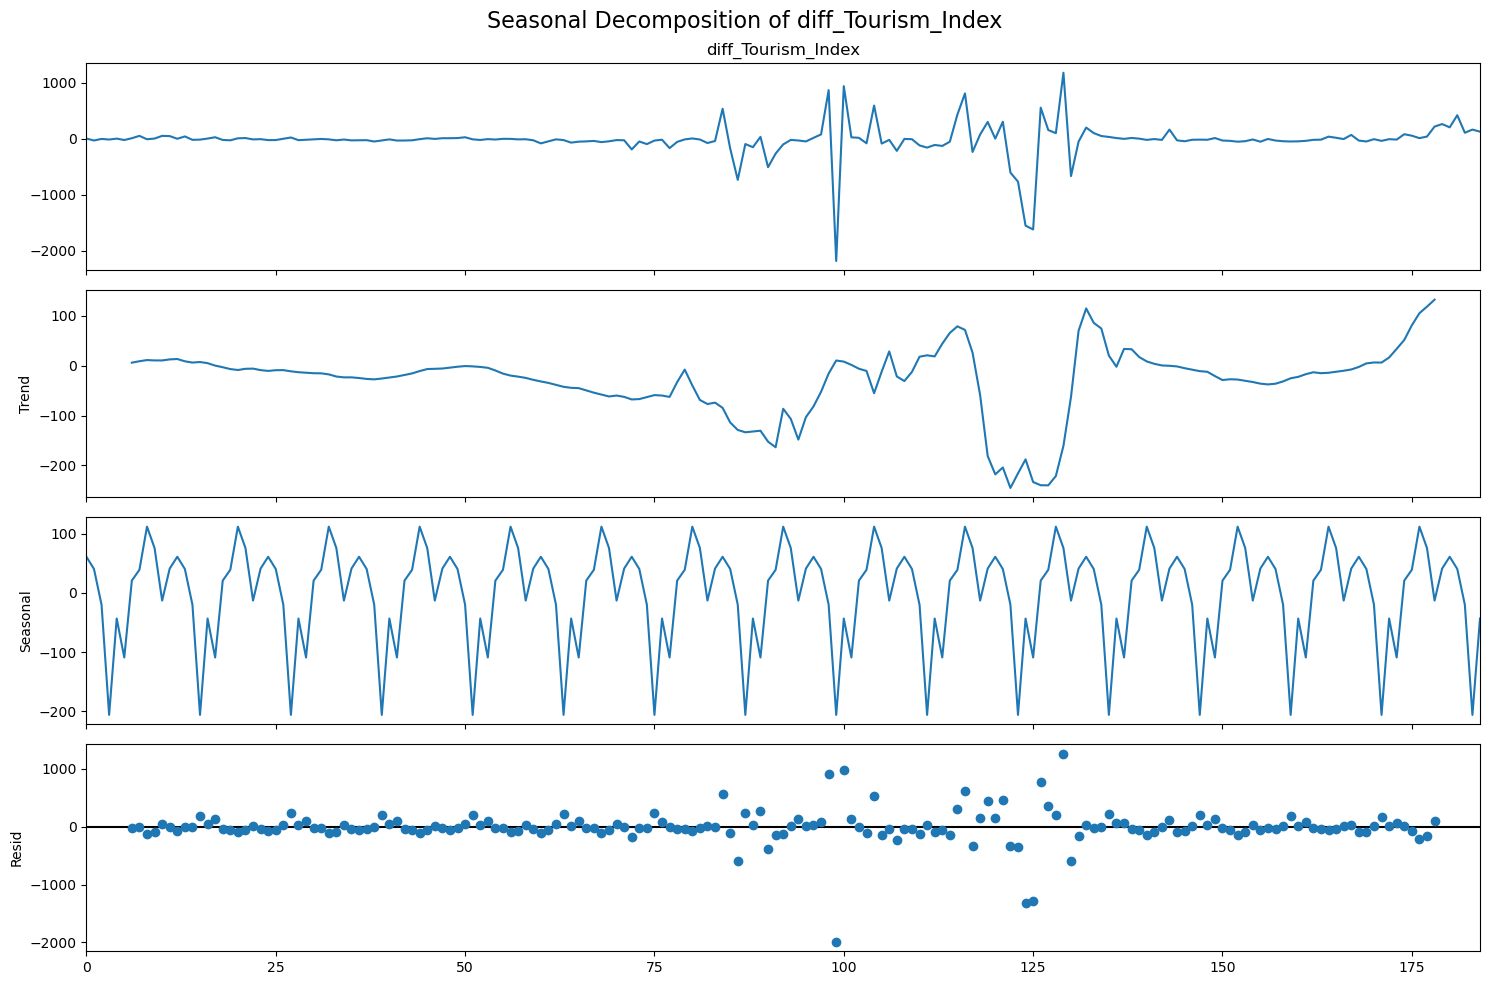

Augmented Dickey-Fuller Test for "diff_decom_GTI"
-----------------------------------------------
Null Hypothesis: Data has a unit root. Non-Stationary.
Significance Level = 0.05
Test Statistic = -14.384099154542222
P-value = 9.050355744376628e-27
Critical Values:
   1%: -3.466398230774071
   5%: -2.8773796387256514
   10%: -2.575213838610586
Is the series stationary? Yes ✅
-----------------------------------------------


In [16]:
# --- Set 'date' as index for decomposition ---
# diff_df.set_index('date', inplace=True)

# --- Decompose diff_Tourism_Index (already differenced series) ---
result = seasonal_decompose(diff_df['diff_Tourism_Index'].dropna(), model='additive', period=12)

# Create seasonally adjusted series
diff_df['diff_decom_Tourism_Index'] = diff_df['diff_Tourism_Index'] - result.seasonal

# --- Plot decomposition ---
plt.rcParams["figure.figsize"] = (15,10) # increase figure size
result.plot()
plt.suptitle('Seasonal Decomposition of diff_Tourism_Index', fontsize=16)
plt.tight_layout()
plt.show()

# --- ADF Test on seasonally adjusted diff_Tourism_Index ---
adf_result = adfuller(diff_df['diff_decom_Tourism_Index'].dropna())
print(f'Augmented Dickey-Fuller Test for "diff_decom_GTI"')
print('-' * 47)
print(f'Null Hypothesis: Data has a unit root. Non-Stationary.')
print(f'Significance Level = 0.05')
print(f'Test Statistic = {adf_result[0]}')
print(f'P-value = {adf_result[1]}')
print('Critical Values:')
for key, val in adf_result[4].items():
    print(f'   {key}: {val}')
print('Is the series stationary? Yes ✅' if adf_result[1] <= 0.05 else 'Is the series stationary? No ❌')
print('-' * 47)

# Optional: Reset index if needed
#diff_df.reset_index(inplace=True)

## 10. Save to csv

In [17]:
diff_df.to_csv("tourism_indicators_after_processing.csv")